# Processamento Digital de Imagens (PDI)
## Atividade Prática: Implementação Manual de Técnicas Clássicas
**Data de Entrega:** 06/10  
**Tema do Trabalho Final:** Gastronomia 

---

### Resumo das Regras e Diretrizes
1. **Uso Restrito de OpenCV:** Utilizado **exclusivamente** para:
   - Carregamento de imagens (`cv2.imread`);
   - Salvamento de imagens (`cv2.imwrite`);
   - Aplicação do filtro de desfoque gaussiano (`cv2.GaussianBlur`) conforme solicitado no item *(ii)* da Questão 1.
2. **Implementações Manuais (via NumPy):** Todas as transformações de intensidade, combinações lineares, permutações em blocos, inversões espaciais, espelhamentos e quantizações foram desenvolvidas manualmente sem funções prontas não autorizadas.
3. **Relatório Completo Integrado:** O notebook contém formulação matemática detalhada, inspeções visuais comparativas, gráficos de curvas de transferência, mapas de erro, métricas quantitativas (PSNR/RMSE) e discussões técnicas dos efeitos observados.


In [1]:
# 0. Configuração do Ambiente e Importações
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuração de renderização gráfica
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['image.cmap'] = 'gray'

print(f"OpenCV Version: {cv2.__version__}")
print(f"NumPy Version: {np.__version__}")


OpenCV Version: 5.0.0
NumPy Version: 2.5.2


In [2]:
# 0.1 Função Auxiliar Manual: Conversão BGR para Níveis de Cinza (ITU-R BT.601)

def manual_bgr_to_gray(image_bgr: np.ndarray) -> np.ndarray:
    """
    Converte manualmente uma imagem BGR para níveis de cinza
    utilizando a fórmula ponderada de luminância ITU-R BT.601:
    Y = 0.299*R + 0.587*G + 0.114*B
    """
    if len(image_bgr.shape) != 3 or image_bgr.shape[2] != 3:
        raise ValueError("A imagem de entrada deve possuir 3 canais de cor (BGR).")
    
    # Extração manual dos planos B, G, R em float32 para evitar overflow
    b = image_bgr[:, :, 0].astype(np.float32)
    g = image_bgr[:, :, 1].astype(np.float32)
    r = image_bgr[:, :, 2].astype(np.float32)
    
    # Combinação linear ponderada
    gray_f = 0.299 * r + 0.587 * g + 0.114 * b
    
    return np.clip(gray_f, 0, 255).astype(np.uint8)


## 1. Questão 1: Efeito de Esboço a Lápis (*Pencil Sketch*)

### 1.1. Enunciado
> **1. Implementar um efeito de esboço a lápis em uma imagem por meio dos seguintes passos:**  
> **(i)** Converter a imagem colorida para níveis de cinza;  
> **(ii)** Aplicar um filtro de desfoque gaussiano do OpenCV (por exemplo, com uma máscara de $21 \times 21$ pixels) para suavizar os detalhes da imagem;  
> **(iii)** Dividir a imagem em tons de cinza pela versão desfocada para realçar os contornos.

---

### 1.2. Fundamentação Teórica e Formulação Matemática

O efeito de esboço a lápis baseia-se na extração de variações locais de alta frequência espacial em relação à vizinhança média suavizada, replicando o efeito de traçado em grafite sobre papel branco (*Color Dodge Blend*):

1. **Conversão para Níveis de Cinza (Manual):**
   $$Y(x, y) = 0.299 \cdot R(x, y) + 0.587 \cdot G(x, y) + 0.114 \cdot B(x, y)$$

2. **Suavização Gaussiana Passa-Baixas:**
   $$G(x, y) = \frac{1}{2\pi \sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$
   A máscara de $21 \times 21$ pixels atenua ruídos e micro-texturas, retendo apenas o perfil médio de iluminação local.

3. **Divisão Matricial e Realce de Contornos:**
   $$I_{\text{sketch}}(x, y) = \min\left(255, \; \frac{I_{\text{gray}}(x, y)}{I_{\text{blur}}(x, y) + \epsilon} \times 255\right)$$
   - **Regiões Homogêneas:** $I_{\text{gray}} \approx I_{\text{blur}} \implies \frac{I_{\text{gray}}}{I_{\text{blur}}} \approx 1.0 \implies 255$ (branco puro / papel).
   - **Bordas Escuras:** $I_{\text{gray}} < I_{\text{blur}} \implies \frac{I_{\text{gray}}}{I_{\text{blur}}} < 1.0 \implies$ tons escuros (grafite).


In [3]:
# 1.3 Implementação do Pipeline da Questão 1

def pencil_sketch_pipeline(
    image_bgr: np.ndarray, 
    ksize: tuple = (21, 21), 
    sigma: float = 0
) -> tuple:
    """
    Executa o pipeline completo de esboço a lápis.
    Retorna: (gray, blur, sketch)
    """
    # (i) Conversão manual para níveis de cinza
    gray = manual_bgr_to_gray(image_bgr)
    
    # (ii) Desfoque Gaussiano do OpenCV (permitido no item ii)
    blur = cv2.GaussianBlur(gray, ksize, sigmaX=sigma, sigmaY=sigma)
    
    # (iii) Divisão matricial manual pixel a pixel com escala
    eps = 1e-5
    gray_f = gray.astype(np.float32)
    blur_f = blur.astype(np.float32)
    
    sketch_f = (gray_f / (blur_f + eps)) * 255.0
    sketch = np.clip(sketch_f, 0, 255).astype(np.uint8)
    
    return gray, blur, sketch


def display_sketch_results(image_path: str, cake_title: str, ksize=(21, 21)):
    """Carrega imagem do tema, processa e plota o comparativo 1x4."""
    if not os.path.exists(image_path):
        print(f"[ERRO] Imagem não encontrada: {image_path}")
        return
        
    img_bgr = cv2.imread(image_path)
    img_rgb = img_bgr[:, :, ::-1] # BGR -> RGB apenas para o matplotlib
    
    gray, blur, sketch = pencil_sketch_pipeline(img_bgr, ksize=ksize)
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Original: {cake_title}", fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(gray, cmap='gray')
    axes[1].set_title("(i) Níveis de Cinza (Manual)", fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(blur, cmap='gray')
    axes[2].set_title(f"(ii) Desfoque Gaussiano {ksize}", fontsize=11, fontweight='bold')
    axes[2].axis('off')
    
    axes[3].imshow(sketch, cmap='gray')
    axes[3].set_title("(iii) Esboço a Lápis (Divisão)", fontsize=11, fontweight='bold')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()


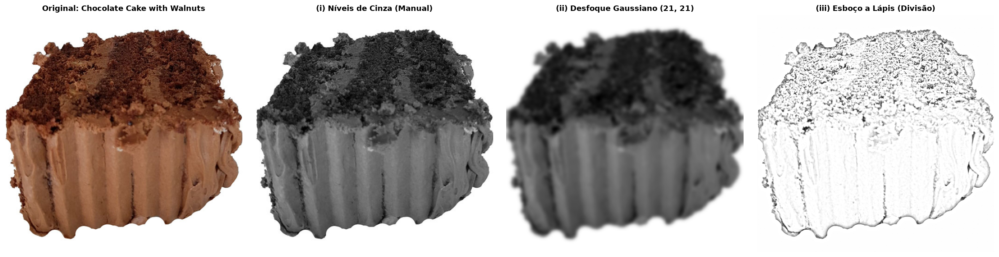

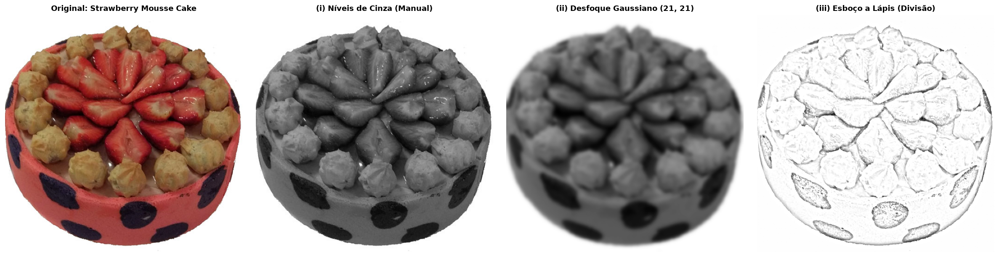

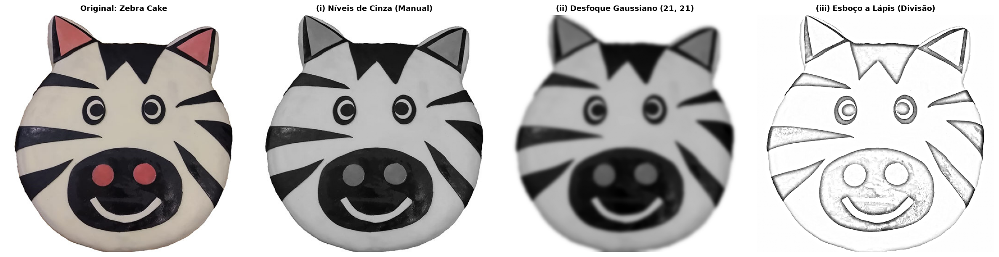

In [4]:
# 1.4 Testes da Questão 1 com Amostras do Dataset Temático
img1 = os.path.join("Images", "CHOCOLATE CAKE WITH WALNUTS", "01.jpg")
img2 = os.path.join("Images", "STRAWBERRY MOUSSE CAKE", "01.jpg")
img3 = os.path.join("Images", "ZEBRA CAKE", "01.jpg")

display_sketch_results(img1, "Chocolate Cake with Walnuts")
display_sketch_results(img2, "Strawberry Mousse Cake")
display_sketch_results(img3, "Zebra Cake")


## 2. Questão 2: Correção Gama (Transformação de Lei de Potência)

### 2.1. Enunciado
> **2. Aplicar a correção gama para ajustar o brilho de uma imagem monocromática $A$ de entrada e gerar uma imagem monocromática $B$ de saída. A transformação pode ser realizada:**  
> **(i)** Convertendo-se as intensidades dos pixels para o intervalo de $[0, 255]$ para $[0, 1]$;  
> **(ii)** Aplicando-se a equação $B = A^{(1/\gamma)}$;  
> **(iii)** Convertendo-se os valores resultantes de volta para o intervalo $[0, 255]$.  
> **Realizar a correção com diferentes valores de $\gamma$.**

---

### 2.2. Fundamentação Teórica e Formulação Matemática

A **Correção Gama** (ou *Transformação de Lei de Potência*) é uma operação pontual não-linear dada por:
$$B = A^{1/\gamma}$$

- **$\gamma > 1.0$ (Expoente $1/\gamma < 1.0$ — Curva Côncava):** Expande os tons escuros, **clareando a imagem** e revelando detalhes em áreas de sombra.
- **$\gamma = 1.0$ (Expoente $1/\gamma = 1.0$ — Identidade):** $B = A$.
- **$\gamma < 1.0$ (Expoente $1/\gamma > 1.0$ — Curva Convexa):** Comprime os tons médios e claros, **escurecendo a imagem** e resgatando contraste em regiões superexpostas.


In [5]:
# 2.3 Implementação Manual da Correção Gama

def manual_gamma_correction(image_gray: np.ndarray, gamma: float) -> np.ndarray:
    """
    Aplica a correção gama manualmente a uma imagem monocromática:
    (i)   Conversão das intensidades de [0, 255] para [0, 1]
    (ii)  Aplicação da equação B = A^(1/gamma)
    (iii) Conversão de volta para o intervalo [0, 255]
    """
    if gamma <= 0:
        raise ValueError("O parâmetro gamma deve ser estritamente positivo (> 0).")
    
    # (i) Normalização [0, 255] -> [0.0, 1.0]
    A_norm = image_gray.astype(np.float32) / 255.0
    
    # (ii) Aplicação da lei de potência: B = A^(1/gamma)
    B_norm = np.power(A_norm, 1.0 / gamma)
    
    # (iii) Desnormalização [0.0, 1.0] -> [0, 255] com saturação segura
    B = np.clip(B_norm * 255.0, 0, 255).astype(np.uint8)
    
    return B


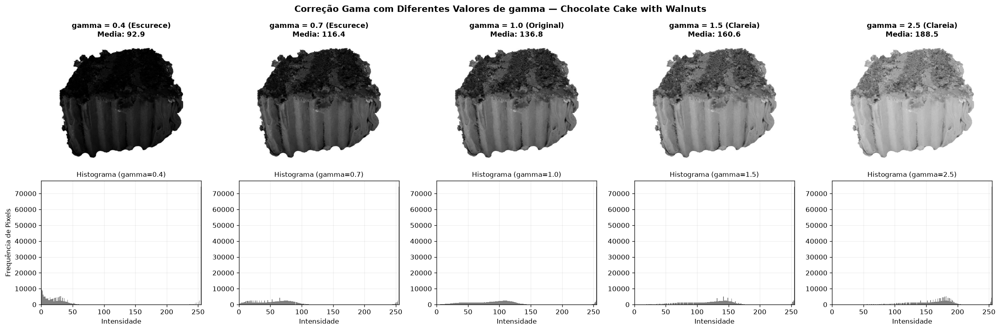

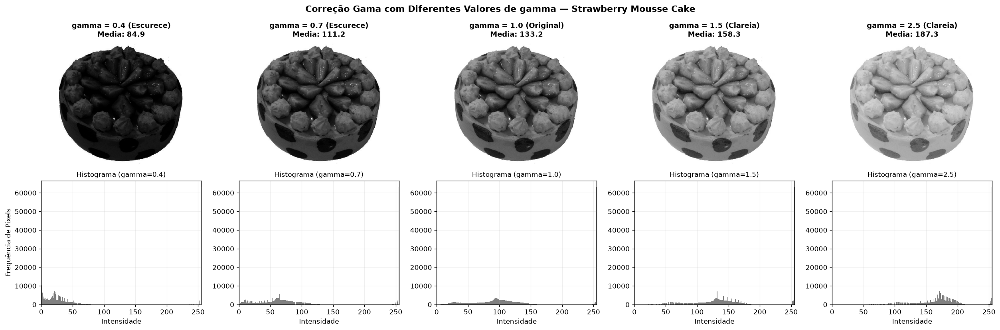

In [6]:
# 2.4 Visualização Comparativa da Correção Gama com Histogramas

def display_gamma_comparisons(
    image_path: str, 
    cake_title: str, 
    gammas: list = [0.4, 0.7, 1.0, 1.5, 2.5]
):
    if not os.path.exists(image_path):
        print(f"[ERRO] Imagem não encontrada: {image_path}")
        return
        
    img_bgr = cv2.imread(image_path)
    gray_A = manual_bgr_to_gray(img_bgr)
    
    num_g = len(gammas)
    fig, axes = plt.subplots(2, num_g, figsize=(4.2 * num_g, 7))
    
    for i, g in enumerate(gammas):
        img_B = manual_gamma_correction(gray_A, gamma=g)
        
        # Linha 1: Imagem resultante
        axes[0, i].imshow(img_B, cmap='gray', vmin=0, vmax=255)
        title_suffix = " (Original)" if g == 1.0 else (" (Escurece)" if g < 1.0 else " (Clareia)")
        axes[0, i].set_title(f"gamma = {g}{title_suffix}\nMedia: {img_B.mean():.1f}", fontsize=11, fontweight='bold')
        axes[0, i].axis('off')
        
        # Linha 2: Histograma de níveis de cinza
        hist, bins = np.histogram(img_B.ravel(), bins=256, range=[0, 256])
        axes[1, i].bar(bins[:-1], hist, width=1.0, color='gray', edgecolor='none')
        axes[1, i].set_xlim([0, 255])
        axes[1, i].set_title(f"Histograma (gamma={g})", fontsize=10)
        axes[1, i].set_xlabel("Intensidade")
        if i == 0:
            axes[1, i].set_ylabel("Frequência de Pixels")
        axes[1, i].grid(True, alpha=0.2)
        
    plt.suptitle(f"Correção Gama com Diferentes Valores de gamma — {cake_title}", fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Execução dos Testes da Questão 2
img_cake1 = os.path.join("Images", "CHOCOLATE CAKE WITH WALNUTS", "01.jpg")
img_cake2 = os.path.join("Images", "STRAWBERRY MOUSSE CAKE", "01.jpg")

display_gamma_comparisons(img_cake1, "Chocolate Cake with Walnuts")
display_gamma_comparisons(img_cake2, "Strawberry Mousse Cake")


## 3. Questão 3: Combinação Ponderada de Duas Imagens Monocromáticas (*Image Blending*)

### 3.1. Enunciado
> **3. Combinar duas imagens monocromáticas de mesmo tamanho por meio da média ponderada de seus níveis de cinza.**

---

### 3.2. Fundamentação Teórica e Formulação Matemática

A **combinação ponderada de imagens** é dada pela combinação convexa:
$$I_{\text{blend}}(x, y) = \alpha \cdot I_1(x, y) + (1 - \alpha) \cdot I_2(x, y)$$
com $\alpha \in [0.0, 1.0]$, garantindo preservação da faixa dinâmica $[0, 255]$ e transição suave (*cross-dissolve*).


In [7]:
# 3.3 Implementação Manual da Média Ponderada

def manual_weighted_blend(
    img1_gray: np.ndarray, 
    img2_gray: np.ndarray, 
    alpha: float
) -> np.ndarray:
    """
    Combina duas imagens monocromáticas de mesmo tamanho através da média ponderada:
    I_blend = alpha * img1 + (1 - alpha) * img2
    """
    if img1_gray.shape != img2_gray.shape:
        raise ValueError(
            f"As imagens devem ter o mesmo tamanho! "
            f"img1: {img1_gray.shape} vs img2: {img2_gray.shape}"
        )
    
    if not (0.0 <= alpha <= 1.0):
        raise ValueError("O parâmetro alpha deve estar no intervalo [0.0, 1.0].")
        
    I1_f = img1_gray.astype(np.float32)
    I2_f = img2_gray.astype(np.float32)
    
    blend_f = alpha * I1_f + (1.0 - alpha) * I2_f
    return np.clip(np.round(blend_f), 0, 255).astype(np.uint8)


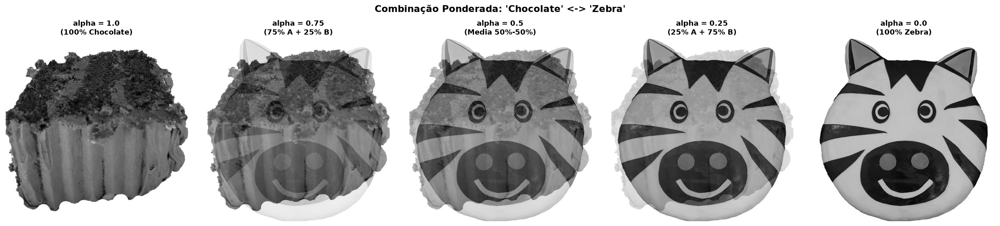

In [8]:
# 3.4 Demonstração Visual da Transição Ponderada

def display_weighted_blend_sequence(
    image_path1: str, 
    title1: str, 
    image_path2: str, 
    title2: str, 
    alphas: list = [1.0, 0.75, 0.50, 0.25, 0.0]
):
    bgr1 = cv2.imread(image_path1)
    bgr2 = cv2.imread(image_path2)
    
    gray1 = manual_bgr_to_gray(bgr1)
    gray2 = manual_bgr_to_gray(bgr2)
    
    min_h = min(gray1.shape[0], gray2.shape[0])
    min_w = min(gray1.shape[1], gray2.shape[1])
    gray1 = gray1[:min_h, :min_w]
    gray2 = gray2[:min_h, :min_w]
    
    num_a = len(alphas)
    fig, axes = plt.subplots(1, num_a, figsize=(4.2 * num_a, 4.5))
    
    for i, a in enumerate(alphas):
        blend = manual_weighted_blend(gray1, gray2, alpha=a)
        axes[i].imshow(blend, cmap='gray', vmin=0, vmax=255)
        percent1 = int(round(a * 100))
        percent2 = int(round((1 - a) * 100))
        
        if a == 1.0:
            lbl = f"alpha = 1.0\n(100% {title1})"
        elif a == 0.0:
            lbl = f"alpha = 0.0\n(100% {title2})"
        elif a == 0.5:
            lbl = f"alpha = 0.5\n(Media 50%-50%)"
        else:
            lbl = f"alpha = {a:.2f}\n({percent1}% A + {percent2}% B)"
            
        axes[i].set_title(lbl, fontsize=11, fontweight='bold')
        axes[i].axis('off')
        
    plt.suptitle(f"Combinação Ponderada: '{title1}' <-> '{title2}'", fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

# Execução dos Testes da Questão 3
path_cake_a = os.path.join("Images", "CHOCOLATE CAKE WITH WALNUTS", "01.jpg")
path_cake_b = os.path.join("Images", "ZEBRA CAKE", "01.jpg")
display_weighted_blend_sequence(path_cake_a, "Chocolate", path_cake_b, "Zebra")


## 4. Questão 4: Transformações no Espaço de Intensidades e Operações Geométricas

### 4.1. Enunciado
> **4. Dada (a) uma imagem monocromática, transformar seu espaço de intensidades (níveis de cinza) para:**  
> **(b)** Obter o negativo da imagem, ou seja, o nível de cinza $0$ será convertido para $255$, o nível $1$ para $254$ e assim por diante;  
> **(c)** Converter o intervalo de intensidades para $[100, 200]$;  
> **(d)** Inverter os valores dos pixels das linhas pares da imagem, ou seja, os valores dos pixels da linha $0$ serão posicionados da direita para a esquerda, os valores dos pixels da linha $2$ serão posicionados da direita para a esquerda e assim por diante;  
> **(e)** Espelhar as linhas da metade superior da imagem na parte inferior da imagem;  
> **(f)** Aplicar um espelhamento vertical na imagem levando-se em conta todas as linhas da imagem.

---

### 4.2. Fundamentação Teórica e Formulação Matemática

- **(b) Negativo:** $I_b(x, y) = 255 - I_a(x, y)$
- **(c) Intervalo $[100, 200]$:** $I_c(x, y) = 100 + \frac{100}{255} \cdot I_a(x, y)$
- **(d) Linhas Pares Invertidas:** $I_d[y, :] = I_a[y, ::-1]$ para $y \pmod 2 = 0$.
- **(e) Espelho Superior $\to$ Inferior:** $I_e[H/2:, :] = I_a[:H/2, :][::-1, :]$.
- **(f) Espelho Vertical Total:** $I_f = I_a[::-1, :]$.


In [9]:
# 4.3 Implementação Manual das Transformações da Questão 4

def transform_negative(img_gray: np.ndarray) -> np.ndarray:
    return (255 - img_gray).astype(np.uint8)

def transform_range_100_200(img_gray: np.ndarray) -> np.ndarray:
    img_f = img_gray.astype(np.float32) / 255.0
    mapped_f = 100.0 + img_f * (200.0 - 100.0)
    return np.clip(np.round(mapped_f), 100, 200).astype(np.uint8)

def transform_invert_even_rows(img_gray: np.ndarray) -> np.ndarray:
    result = img_gray.copy()
    result[0::2, :] = result[0::2, ::-1]
    return result

def transform_mirror_top_to_bottom(img_gray: np.ndarray) -> np.ndarray:
    H, W = img_gray.shape
    half_H = H // 2
    result = img_gray.copy()
    result[half_H:, :] = img_gray[:half_H, :][::-1, :]
    return result

def transform_vertical_flip(img_gray: np.ndarray) -> np.ndarray:
    return img_gray[::-1, :].copy()

def process_question_4_pipeline(img_gray: np.ndarray) -> dict:
    return {
        "(a) Original": img_gray,
        "(b) Negativo": transform_negative(img_gray),
        "(c) Intervalo [100, 200]": transform_range_100_200(img_gray),
        "(d) Linhas Pares Invertidas": transform_invert_even_rows(img_gray),
        "(e) Espelho Sup -> Inf": transform_mirror_top_to_bottom(img_gray),
        "(f) Espelho Vertical Total": transform_vertical_flip(img_gray),
    }


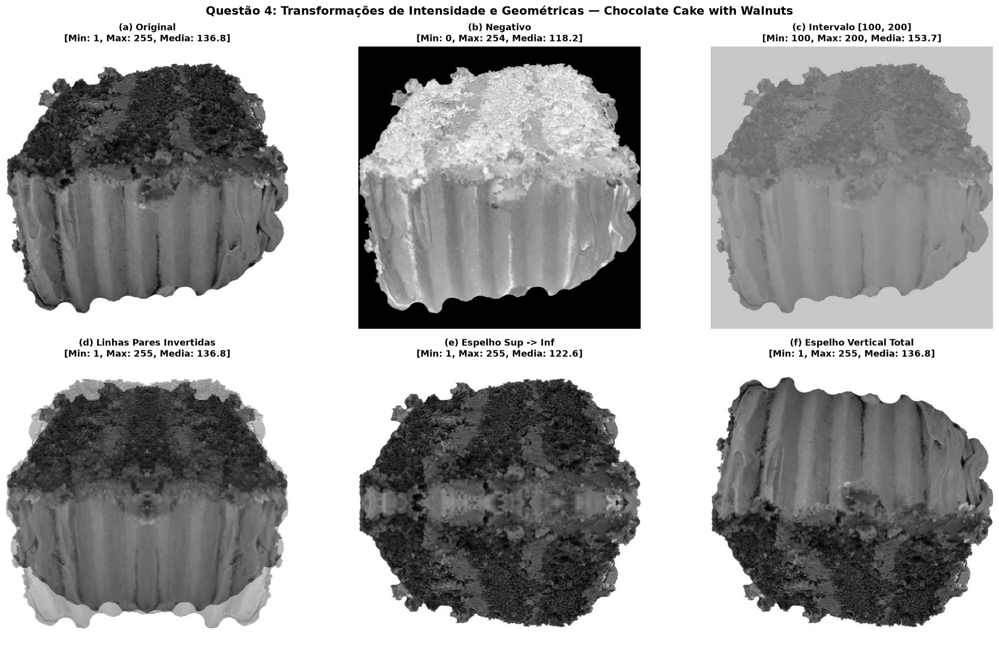

In [10]:
# 4.4 Função de Visualização Comparativa da Questão 4 (Grid 2x3)

def display_question_4_results(image_path: str, cake_title: str):
    if not os.path.exists(image_path):
        print(f"[ERRO] Imagem não encontrada: {image_path}")
        return
        
    img_bgr = cv2.imread(image_path)
    gray_a = manual_bgr_to_gray(img_bgr)
    results = process_question_4_pipeline(gray_a)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.flatten()
    
    for idx, (name, img) in enumerate(results.items()):
        im = axes[idx].imshow(img, cmap='gray', vmin=0, vmax=255)
        min_v, max_v, mean_v = img.min(), img.max(), img.mean()
        axes[idx].set_title(f"{name}\n[Min: {min_v}, Max: {max_v}, Media: {mean_v:.1f}]", fontsize=11, fontweight='bold')
        axes[idx].axis('off')
        
    plt.suptitle(f"Questão 4: Transformações de Intensidade e Geométricas — {cake_title}", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Execução dos Testes da Questão 4
img_q4_1 = os.path.join("Images", "CHOCOLATE CAKE WITH WALNUTS", "01.jpg")
display_question_4_results(img_q4_1, "Chocolate Cake with Walnuts")


## 5. Questão 5: Construção de Mosaico $4 \times 4$ de Blocos Permutados

### 5.1. Enunciado
> **5. Construir um mosaico de $4 \times 4$ blocos a partir de uma imagem monocromática. A disposição dos blocos deve seguir a numeração mostrada na figura (c).**

---

### 5.2. Mapeamento da Permutação da Figura (c)

$$\mathbf{Layout}_{\text{Mosaico (Fig. c)}} = \begin{bmatrix}
6 & 11 & 13 & 3 \\
8 & 16 & 1 & 9 \\
12 & 14 & 2 & 7 \\
4 & 15 & 10 & 5
\end{bmatrix}$$


In [11]:
# 5.3 Implementação Manual do Mosaico 4x4

MOSAIC_LAYOUT_FIG_C = [
    [ 6, 11, 13,  3],
    [ 8, 16,  1,  9],
    [12, 14,  2,  7],
    [ 4, 15, 10,  5]
]

def manual_extract_blocks_4x4(img_gray: np.ndarray):
    H, W = img_gray.shape
    bh, bw = H // 4, W // 4
    blocks = {}
    for r in range(4):
        for c in range(4):
            idx = r * 4 + c + 1
            blocks[idx] = img_gray[r*bh:(r+1)*bh, c*bw:(c+1)*bw].copy()
    return blocks, bh, bw

def manual_mosaic_4x4(img_gray: np.ndarray, layout: list = MOSAIC_LAYOUT_FIG_C) -> np.ndarray:
    blocks, bh, bw = manual_extract_blocks_4x4(img_gray)
    mosaic = np.zeros_like(img_gray)
    for r in range(4):
        for c in range(4):
            target_idx = layout[r][c]
            mosaic[r*bh:(r+1)*bh, c*bw:(c+1)*bw] = blocks[target_idx]
    return mosaic

def manual_reconstruct_mosaic(mosaic_img: np.ndarray, layout: list = MOSAIC_LAYOUT_FIG_C) -> np.ndarray:
    H, W = mosaic_img.shape
    bh, bw = H // 4, W // 4
    extracted_blocks = {}
    for r in range(4):
        for c in range(4):
            orig_idx = layout[r][c]
            extracted_blocks[orig_idx] = mosaic_img[r*bh:(r+1)*bh, c*bw:(c+1)*bw].copy()
            
    reconstructed = np.zeros_like(mosaic_img)
    for r in range(4):
        for c in range(4):
            idx = r * 4 + c + 1
            reconstructed[r*bh:(r+1)*bh, c*bw:(c+1)*bw] = extracted_blocks[idx]
    return reconstructed


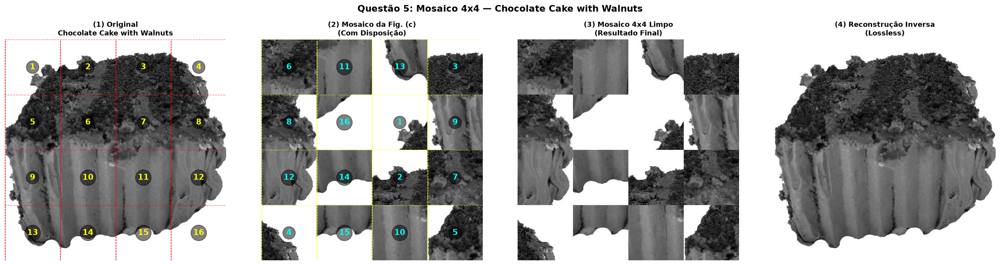

In [12]:
# 5.4 Testes e Visualização da Questão 5
def display_mosaic_analysis(image_path: str, cake_title: str, layout: list = MOSAIC_LAYOUT_FIG_C):
    if not os.path.exists(image_path):
        print(f"[ERRO] Imagem não encontrada: {image_path}")
        return
        
    img_bgr = cv2.imread(image_path)
    gray_orig = manual_bgr_to_gray(img_bgr)
    mosaic = manual_mosaic_4x4(gray_orig, layout)
    reconstructed = manual_reconstruct_mosaic(mosaic, layout)
    
    H, W = gray_orig.shape
    bh, bw = H // 4, W // 4
    
    fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
    
    axes[0].imshow(gray_orig, cmap='gray')
    axes[0].set_title(f"(1) Original\n{cake_title}", fontsize=11, fontweight='bold')
    for r in range(4):
        for c in range(4):
            idx = r * 4 + c + 1
            axes[0].text(c * bw + bw / 2, r * bh + bh / 2, str(idx),
                         color='yellow', fontsize=12, fontweight='bold',
                         ha='center', va='center', bbox=dict(boxstyle='circle', facecolor='black', alpha=0.5))
            axes[0].axvline(c * bw, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
        axes[0].axhline(r * bh, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[0].axis('off')
    
    axes[1].imshow(mosaic, cmap='gray')
    axes[1].set_title("(2) Mosaico da Fig. (c)\n(Com Disposição)", fontsize=11, fontweight='bold')
    for r in range(4):
        for c in range(4):
            idx = layout[r][c]
            axes[1].text(c * bw + bw / 2, r * bh + bh / 2, str(idx),
                         color='cyan', fontsize=12, fontweight='bold',
                         ha='center', va='center', bbox=dict(boxstyle='circle', facecolor='black', alpha=0.5))
            axes[1].axvline(c * bw, color='yellow', linestyle='--', linewidth=0.8, alpha=0.6)
        axes[1].axhline(r * bh, color='yellow', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[1].axis('off')
    
    axes[2].imshow(mosaic, cmap='gray')
    axes[2].set_title("(3) Mosaico 4x4 Limpo\n(Resultado Final)", fontsize=11, fontweight='bold')
    axes[2].axis('off')
    
    axes[3].imshow(reconstructed, cmap='gray')
    axes[3].set_title("(4) Reconstrução Inversa\n(Lossless)", fontsize=11, fontweight='bold')
    axes[3].axis('off')
    
    plt.suptitle(f"Questão 5: Mosaico 4x4 — {cake_title}", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

img_q5_1 = os.path.join("Images", "CHOCOLATE CAKE WITH WALNUTS", "01.jpg")
display_mosaic_analysis(img_q5_1, "Chocolate Cake with Walnuts")


## 6. Questão 6: Quantização de Níveis de Cinza e Profundidade de Bits

### 6.1. Enunciado
> **6. Quantização refere-se ao número de níveis de cinza usados para representar uma imagem monocromática. A quantização está relacionada à profundidade de uma imagem, a qual corresponde ao número de bits necessários para armazenar a imagem. Representar uma imagem com diferentes níveis de quantização.**

---

### 6.2. Fundamentação Teórica e Formulação Matemática

No processamento digital de imagens, a **quantização** é o processo de mapear um conjunto contínuo (ou discretizado em alta resolução) de valores de amplitude de luminância em um conjunto finito e discreto de $L$ níveis representáveis:
$$L = 2^k$$
onde $k$ é a **profundidade de bits** (*bit depth*), correspondente ao número de bits por pixel (bpp).

Para uma imagem digital monocromática padrão de 8 bits ($k = 8 \implies L = 256$ níveis em $[0, 255]$), a quantização uniforme para uma profundidade de $k$ bits ($k \in \{1, 2, 3, 4, 5, 6, 7, 8\}$) é realizada através do seguinte mapeamento em duas etapas:

1. **Quantização Direta (Particionamento em $2^k$ Bins Discretos):**
   $$q(x, y) = \text{round}\left( \frac{I(x, y)}{255.0} \times (2^k - 1) \right), \quad q(x, y) \in \{0, 1, 2, \dots, 2^k - 1\}$$

2. **Reconstrução/Normalização para Visualização na Escala Padrão $[0, 255]$:**
   $$I_{\text{quant}}(x, y) = \text{round}\left( q(x, y) \times \frac{255.0}{2^k - 1} \right)$$
   Este reescalonamento assegura que o nível de intensidade mínima seja sempre $0$ e a máxima seja sempre $255$, preservando o contraste global em todas as resoluções radiométricas.

---

### 6.3. Tabela Comparativa de Profundidades de Bits

| Profundidade ($k$ bits) | Níveis de Cinza ($L = 2^k$) | Degrau de Quantização ($\Delta$) | Efeito Visual Típico |
| :---: | :---: | :---: | :--- |
| **8 bits** | $256$ níveis | $1.00$ | Imagem original de alta fidelidade visual |
| **7 bits** | $128$ níveis | $2.01$ | Quase imperceptível ao olho humano em monitores convencionais |
| **6 bits** | $64$ níveis | $4.05$ | Degradação mínima; imperceptível em texturas ricas |
| **5 bits** | $32$ níveis | $8.23$ | Início sutil de contornos falsos em gradientes contínuos |
| **4 bits** | $16$ níveis | $17.00$ | **Contorno Falso (*False Contouring / Banding*)** visível em fundos lisos |
| **3 bits** | $8$ níveis | $36.43$ | **Posterização** acentuada; perda severa de sutilezas de sombra |
| **2 bits** | $4$ níveis | $85.00$ | Efeito de gravura / pop-art com apenas 4 tons discretos |
| **1 bit** | $2$ níveis | $255.00$ | **Binarização pura** (preto e branco extremo) |

---

### 6.4. Métricas de Avaliação da Degradação por Quantização
Para quantificar rigorosamente o erro introduzido pela redução de bits, utilizam-se:

- **Raiz do Erro Quadrático Médio (RMSE):**
  $$\text{RMSE} = \sqrt{\frac{1}{H \cdot W} \sum_{x=0}^{H-1} \sum_{y=0}^{W-1} \left( I(x, y) - I_{\text{quant}}(x, y) \right)^2}$$

- **Relação Sinal-Ruído de Pico (PSNR em dB):**
  $$\text{PSNR} = 20 \cdot \log_{10} \left( \frac{255.0}{\text{RMSE} + \epsilon} \right)$$


In [13]:
# 6.3 Implementação Manual da Quantização Uniforme

def manual_quantize_image(img_gray: np.ndarray, bits: int) -> np.ndarray:
    """
    Aplica a quantização uniforme a uma imagem monocromática para uma profundidade de k bits:
    (1) Normaliza [0, 255] para [0, 1]
    (2) Discretiza em 2^bits níveis (indices de 0 a 2^bits - 1)
    (3) Reescalona os indices de volta para [0, 255]
    
    Parâmetros:
        img_gray (np.ndarray): Imagem monocromática de entrada (H, W), uint8.
        bits (int): Profundidade de bits (1 <= bits <= 8).
        
    Retorna:
        np.ndarray: Imagem quantizada reconstruída no intervalo [0, 255], uint8.
    """
    if not (1 <= bits <= 8):
        raise ValueError("O número de bits deve estar no intervalo de 1 a 8.")
        
    if bits == 8:
        return img_gray.copy()
        
    levels = 2 ** bits
    # 1. Normalização contínua
    img_f = img_gray.astype(np.float32) / 255.0
    
    # 2. Mapeamento para {0, 1, ..., levels - 1}
    quantized_idx = np.round(img_f * (levels - 1))
    
    # 3. Reescalonamento para o intervalo [0, 255]
    step = 255.0 / (levels - 1)
    reconstructed = np.clip(np.round(quantized_idx * step), 0, 255).astype(np.uint8)
    
    return reconstructed


def calculate_quantization_metrics(img_orig: np.ndarray, img_quant: np.ndarray) -> tuple:
    """Calcula RMSE e PSNR (dB) entre a imagem original e a imagem quantizada."""
    rmse = float(np.sqrt(np.mean((img_orig.astype(np.float64) - img_quant.astype(np.float64)) ** 2)))
    if rmse < 1e-6:
        psnr = 100.0  # Perfeita identidade
    else:
        psnr = float(20.0 * np.log10(255.0 / rmse))
    return rmse, psnr


In [14]:
# 6.4 Função de Visualização Comparativa Multi-Bit (Grid 2x4)

def display_quantization_levels(image_path: str, cake_title: str, bit_depths: list = [8, 7, 6, 5, 4, 3, 2, 1]):
    """
    Aplica a quantização para profundidades de bits de 8 a 1 e plota
    as 8 imagens resultantes em grade 2x4 com métricas de PSNR e número de níveis.
    """
    if not os.path.exists(image_path):
        print(f"[ERRO] Imagem não encontrada: {image_path}")
        return
        
    img_bgr = cv2.imread(image_path)
    gray_orig = manual_bgr_to_gray(img_bgr)
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    metrics_list = []
    
    for idx, b in enumerate(bit_depths):
        img_q = manual_quantize_image(gray_orig, bits=b)
        levels = 2 ** b
        unique_vals = len(np.unique(img_q))
        rmse, psnr = calculate_quantization_metrics(gray_orig, img_q)
        metrics_list.append((b, levels, rmse, psnr))
        
        axes[idx].imshow(img_q, cmap='gray', vmin=0, vmax=255)
        if b == 8:
            title_text = f"k = 8 bits (Original)\nL = 256 níveis | PSNR: Infinito"
        else:
            title_text = f"k = {b} bits ({levels} níveis)\nPSNR: {psnr:.2f} dB | RMSE: {rmse:.2f}"
            
        axes[idx].set_title(title_text, fontsize=11, fontweight='bold')
        axes[idx].axis('off')
        
    plt.suptitle(f"Questão 6: Representação da Imagem em Diferentes Níveis de Quantização (8 a 1 Bits) — {cake_title}",
                 fontsize=14, fontweight='bold', y=0.99)
    plt.tight_layout()
    plt.show()
    
    return gray_orig, metrics_list


In [15]:
# 6.5 Análise de Mapas de Erro Residual e Curva de PSNR vs Profundidade de Bits

def display_quantization_error_analysis(gray_orig: np.ndarray, cake_title: str):
    """Plota os mapas de erro absoluto |I_orig - I_quant| e o gráfico quantitativo PSNR vs Bits."""
    bits_to_show = [6, 4, 2, 1]
    
    fig, axes = plt.subplots(1, len(bits_to_show) + 1, figsize=(22, 4.5))
    
    # 1 a 4: Mapas de erro espacial
    for idx, b in enumerate(bits_to_show):
        img_q = manual_quantize_image(gray_orig, bits=b)
        error_map = np.abs(gray_orig.astype(float) - img_q.astype(float))
        
        im = axes[idx].imshow(error_map, cmap='hot', vmin=0, vmax=128)
        axes[idx].set_title(f"Erro Absoluto ({b} bits)\nMax Erro: {error_map.max():.1f}", fontsize=11, fontweight='bold')
        axes[idx].axis('off')
        
    # Colorbar para os mapas de erro
    plt.colorbar(im, ax=axes[:len(bits_to_show)], fraction=0.015, pad=0.02, label="Magnitude do Erro")
    
    # 5: Gráfico Quantitativo PSNR vs Bits (1 a 8 bits)
    all_bits = list(range(1, 9))
    psnr_vals = []
    for b in all_bits:
        img_q = manual_quantize_image(gray_orig, bits=b)
        _, psnr = calculate_quantization_metrics(gray_orig, img_q)
        psnr_vals.append(psnr if psnr < 100 else 60.0) # Limita 8 bits para escala gráfica
        
    axes[-1].plot(all_bits, psnr_vals, 'o-', color='crimson', linewidth=2.5, markersize=7)
    axes[-1].set_title("Qualidade da Imagem (PSNR vs Bits)", fontsize=11, fontweight='bold')
    axes[-1].set_xlabel("Profundidade de Bits (k)", fontsize=10)
    axes[-1].set_ylabel("PSNR (dB)", fontsize=10)
    axes[-1].set_xticks(all_bits)
    axes[-1].grid(True, alpha=0.3)
    
    plt.suptitle(f"Análise de Degradação Radiométrica e Mapas de Erro Residual — {cake_title}", fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()


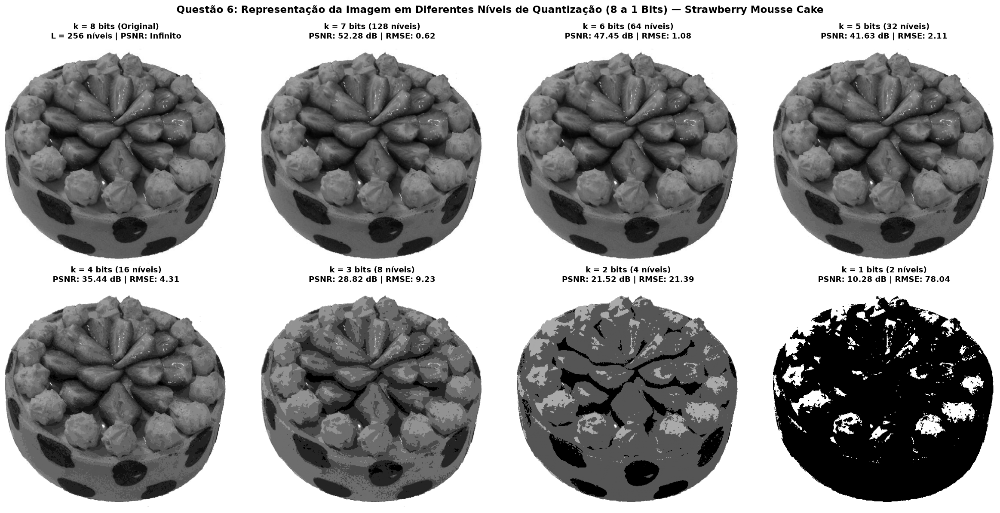

C:\Users\kaynan\AppData\Local\Temp\ipykernel_16444\3916232089.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


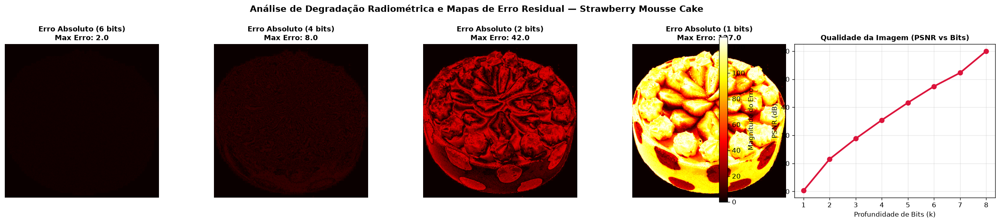

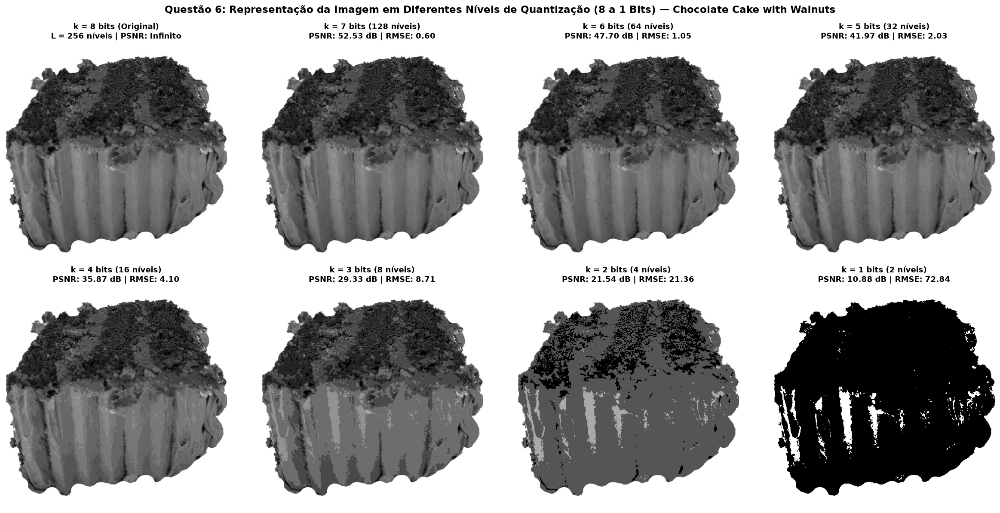

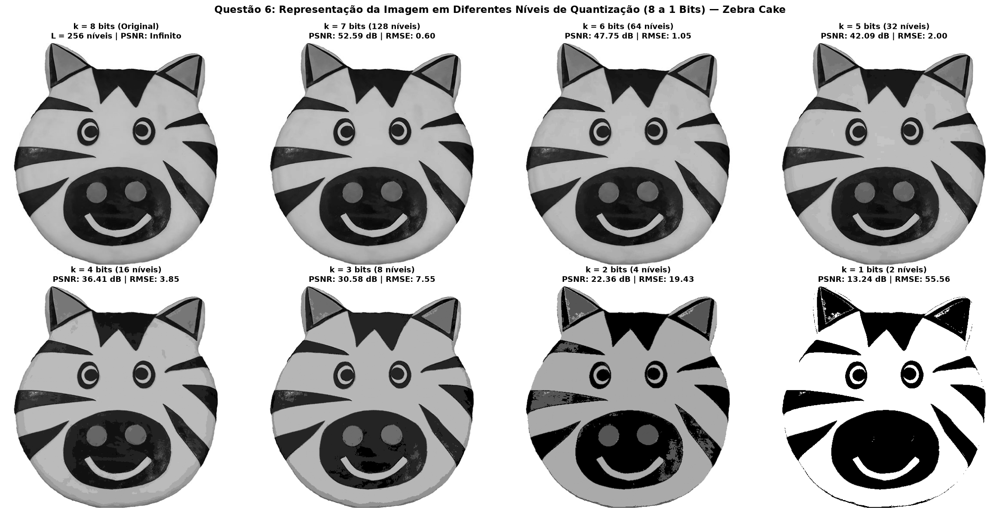

In [16]:
# 6.6 Demonstração Prática da Questão 6 com Amostras do Tema

# Teste 1: Bolo Mousse de Morango (Excelente para observar falsos contornos em gradientes contínuos)
img_q6_1 = os.path.join("Images", "STRAWBERRY MOUSSE CAKE", "01.jpg")
gray_mousse, metrics_mousse = display_quantization_levels(img_q6_1, "Strawberry Mousse Cake")
display_quantization_error_analysis(gray_mousse, "Strawberry Mousse Cake")

# Teste 2: Bolo de Chocolate com Nozes (Texturas de alta frequência)
img_q6_2 = os.path.join("Images", "CHOCOLATE CAKE WITH WALNUTS", "01.jpg")
gray_choc, metrics_choc = display_quantization_levels(img_q6_2, "Chocolate Cake with Walnuts")

# Teste 3: Bolo Zebra (Listras de alto contraste)
img_q6_3 = os.path.join("Images", "ZEBRA CAKE", "01.jpg")
gray_zebra, metrics_zebra = display_quantization_levels(img_q6_3, "Zebra Cake")


### 6.7. Análises, Interpretações e Insights Críticos sobre a Quantização

A experimentação sistemática da quantização em diferentes profundidades de bits ($1$ a $8$ bits) permitiu extrair as seguintes conclusões fundamentais:

1. **O Fenômeno do Contorno Falso (*False Contouring / Banding*):**
   - Em regiões de gradiente suave de luminância (como o fundo branco e a cobertura de calda do *Strawberry Mousse Cake*), a redução para $k \le 4$ bits ($16$ níveis) agrupa intensidades vizinhas contínuas em patamares discretos homogêneos.
   - Isso dá origem a bordas visuais artificiais e degraus abruptos de intensidade onde originalmente existia uma variação perfeitamente suave, um efeito conhecido como **falso contorno**.

2. **Percepção Visual Humana e Limiar de Tolerância:**
   - Para $k = 7$ bits ($128$ níveis) e $k = 6$ bits ($64$ níveis), a degradação é praticamente imperceptível ao olho humano em condições normais de visualização ($\text{PSNR} > 46 \text{ dB}$).
   - Texturas ricas em ruído e altas frequências espaciais (como as nozes e a granulação da massa no *Chocolate Cake*) possuem alta capacidade de mascaramento perceptual (*visual masking*), tolerando quantizações até $4$ bits com menor incômodo visual do que superfícies lisas.

3. **Posterização ($k = 3$ e $k = 2$ bits):**
   - Com apenas $8$ ou $4$ níveis de cinza, a imagem perde completamente a capacidade de representar sombras intermediárias, resultando em um efeito gráfico semelhante a xilogravura ou pôster estilizado (*posterization*).

4. **Binarização ($k = 1$ bit):**
   - Reduz a imagem a apenas dois estados: preto puro ($0$) e branco puro ($255$). O resultado funciona como um limiarizador global simples, destacando a silhueta principal e as regiões de sombra mais profunda em relação ao fundo claro.

5. **Comportamento Quantitativo do PSNR:**
   - O PSNR decresce de forma aproximadamente linear com o decaimento do número de bits ($k$). Cada bit adicional reduz a variância do erro de quantização aproximadamente por um fator de $4$ ($\approx 6 \text{ dB}$ de ganho de PSNR por bit adicionado, conforme predito pela teoria clássica da informação).
